# Micro Proyecto 1 - Generacion de Musica con Redes Neuronales (GPU T4 v2)
**Curso:** Modelos avanzados para el Procesamiento de Lenguaje Natural  
**Universidad de Los Andes - Ruben Manrique**

### Mejoras v2
- Augmentacion por transposicion de pitch (x11 datos de entrenamiento)
- Atencion (Bahdanau) sobre salidas del LSTM
- `LAMBDA_PITCH=2.0` (mayor peso al pitch en la loss)
- 100 epocas con CosineAnnealingLR

## Instrucciones para Google Colab (T4)
1. Activa GPU: `Runtime > Change runtime type > T4 GPU`
2. Ejecuta la celda de instalacion
3. **Reinicia el runtime** (`Runtime > Restart runtime`)
4. Sube la carpeta `beeth` a `/content/beeth/` usando el panel de archivos
5. Ejecuta el resto de celdas en orden


## 1. Instalacion de dependencias

> Despues de ejecutar esta celda, ve a **Runtime > Restart runtime** antes de continuar.

In [1]:
!apt-get install -y fluidsynth > /dev/null 2>&1
%pip install pretty_midi --quiet
print('Instalacion completa. Reinicia el runtime (Runtime > Restart runtime) antes de continuar.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 62.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.0 MB/s eta 0:00:00
Instalacion completa. Reinicia el runtime (Runtime > Restart runtime) antes de continuar.


## 2. Importaciones y configuracion

In [2]:
import os, glob, random
import numpy as np
import pretty_midi
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.io.wavfile as wavfile
from IPython.display import Image, display

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
assert DEVICE.type == 'cuda', 'GPU no detectada. Ve a Runtime > Change runtime type > T4 GPU'
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

DATASET_PATH = '/content/beeth'
OUTPUT_DIR   = '/content'

CONTEXT_SIZE = 32
BATCH_SIZE   = 512
EPOCHS       = 100
LR           = 1e-3
WEIGHT_DECAY = 1e-4
LAMBDA_PITCH = 2.0   # v2: mayor peso al pitch
LAMBDA_STEP  = 0.5
LAMBDA_DUR   = 0.5
NUM_PITCHES  = 128
EMBED_DIM    = 64
HIDDEN_DIM   = 256
NUM_LAYERS   = 2
DROPOUT      = 0.3
TOP_K        = 10

print('Configuracion v2 lista.')
print(f'Dataset path existe: {os.path.exists(DATASET_PATH)}')

Dispositivo: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4
VRAM disponible: 15.6 GB
Configuracion v2 lista.
Dataset path existe: True


## 3. Carga del dataset

In [3]:
midi_files = (glob.glob(os.path.join(DATASET_PATH, '*.mid')) +
              glob.glob(os.path.join(DATASET_PATH, '*.MID')) +
              glob.glob(os.path.join(DATASET_PATH, '*.midi')))
random.shuffle(midi_files)
print(f'Archivos MIDI encontrados: {len(midi_files)}')
assert len(midi_files) > 0, f'No se encontraron MIDIs en {DATASET_PATH}. Verifica la ruta.'

def extract_notes(path):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        if not pm.instruments: return []
        ins = pm.instruments[0]
        notes = sorted(ins.notes, key=lambda n: n.start)
        out, prev = [], None
        for n in notes:
            step = n.start - prev if prev is not None else 0.0
            dur  = n.end - n.start
            if dur <= 0: prev = n.start; continue
            out.append({'pitch': n.pitch, 'step': step,
                        'duration': dur, 'velocity': n.velocity})
            prev = n.start
        return out
    except Exception as e:
        print(f'  [WARN] {os.path.basename(path)}: {e}')
        return []

all_sequences = []
for f in midi_files:
    seq = extract_notes(f)
    if len(seq) > CONTEXT_SIZE:
        all_sequences.append(seq)
all_notes = [n for seq in all_sequences for n in seq]
print(f'Archivos validos: {len(all_sequences)}')
print(f'Total notas: {len(all_notes):,}')

Archivos MIDI encontrados: 29
Archivos validos: 29
Total notas: 53,392


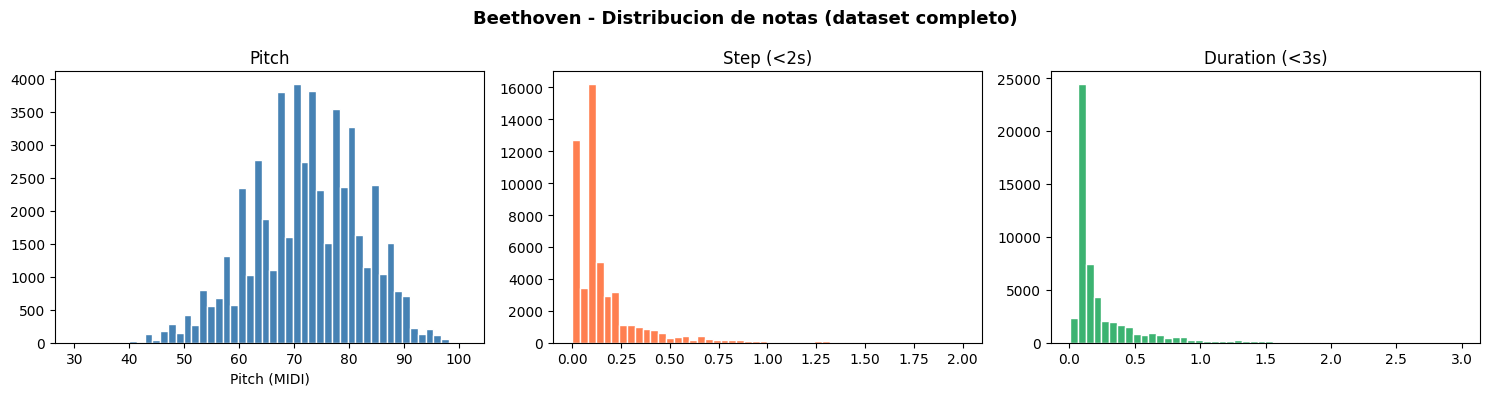

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist([n['pitch'] for n in all_notes], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Pitch'); axes[0].set_xlabel('Pitch (MIDI)')
axes[1].hist([n['step'] for n in all_notes if n['step'] < 2], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Step (<2s)')
axes[2].hist([n['duration'] for n in all_notes if n['duration'] < 3], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Duration (<3s)')
plt.suptitle('Beethoven - Distribucion de notas (dataset completo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_notas.png'), dpi=120)
plt.show()

## 4. Normalizacion

In [5]:
sl = np.log1p([n['step']     for n in all_notes]).astype(np.float32)
dl = np.log1p([n['duration'] for n in all_notes]).astype(np.float32)
SM, SS = sl.mean(), sl.std() + 1e-8
DM, DS = dl.mean(), dl.std() + 1e-8

def ns(s):  return (np.log1p(s) - SM) / SS
def nd(d):  return (np.log1p(d) - DM) / DS
def dns(s): return float(np.expm1(np.clip(s, -10, 10) * SS + SM))
def dnd(d): return float(np.expm1(np.clip(d, -10, 10) * DS + DM))

print(f'step     log-mean={SM:.4f}  log-std={SS:.4f}')
print(f'duration log-mean={DM:.4f}  log-std={DS:.4f}')

step     log-mean=0.1516  log-std=0.1987
duration log-mean=0.2146  log-std=0.2171


## 5. Dataset con ventana deslizante + Augmentacion

In [6]:
# Split por archivo ANTES de augmentar para evitar data leakage
split = int(len(all_sequences) * 0.9)
train_seqs_orig = all_sequences[:split]
val_seqs        = all_sequences[split:]

# Augmentacion: transponer +-1 a +-5 semitonos (solo train)
def transpose_seq(seq, shift):
    return [{'pitch': max(0, min(127, n['pitch'] + shift)),
             'step': n['step'], 'duration': n['duration'],
             'velocity': n['velocity']} for n in seq]

train_seqs = []
for seq in train_seqs_orig:
    train_seqs.append(seq)
    for shift in [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5]:
        train_seqs.append(transpose_seq(seq, shift))
random.shuffle(train_seqs)
print(f'Archivos train originales: {len(train_seqs_orig)}')
print(f'Secuencias train tras augmentacion x11: {len(train_seqs)}')
print(f'Archivos val: {len(val_seqs)}')

class MusicDS(Dataset):
    def __init__(self, sequences, ctx):
        self.X, self.Y = [], []
        for seq in sequences:
            for i in range(len(seq) - ctx):
                x = np.array([[n['pitch'], ns(n['step']), nd(n['duration'])]
                              for n in seq[i:i+ctx]], dtype=np.float32)
                t = seq[i+ctx]
                self.X.append(x)
                self.Y.append((t['pitch'], ns(t['step']), nd(t['duration'])))
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (torch.tensor(self.X[i]),
                torch.tensor(self.Y[i][0], dtype=torch.long),
                torch.tensor(self.Y[i][1], dtype=torch.float32),
                torch.tensor(self.Y[i][2], dtype=torch.float32))

train_ds = MusicDS(train_seqs, CONTEXT_SIZE)
val_ds   = MusicDS(val_seqs,   CONTEXT_SIZE)
train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,
                      num_workers=2, pin_memory=True)
val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
                      num_workers=2, pin_memory=True)
print(f'Ejemplos train: {len(train_ds):,} | val: {len(val_ds):,} | batches/epoch: {len(train_ld)}')

Archivos train originales: 26
Secuencias train tras augmentacion x11: 286
Archivos val: 3
Ejemplos train: 522,962 | val: 4,922 | batches/epoch: 1021


## 6. Arquitectura del Modelo v2

### Descripcion

1. **`nn.Embedding(128->64)`**: convierte pitch categorico en vector denso de 64 dim.
2. **`nn.Linear(2->64)`**: proyecta `step` y `duration` al mismo espacio.
3. **Concat + LayerNorm**: combina ambas representaciones (dim=128).
4. **LSTM (2 capas, hidden=256)**: captura dependencias temporales.
5. **Atencion Bahdanau**: ponderar cada paso del contexto segun su relevancia para predecir la siguiente nota. Reemplaza la seleccion del ultimo estado oculto.
6. **LayerNorm + Dropout(0.3)**: regularizacion.
7. **3 cabezas de salida**: Pitch (CrossEntropy x2.0), Step y Duration (MSE x0.5).

### Funcion de perdida compuesta v2
`L = 2.0 * CrossEntropy(pitch) + 0.5 * MSE(step) + 0.5 * MSE(duration)`

### Mejoras respecto a v1
- Augmentacion x11 por transposicion de pitch
- Atencion Bahdanau sobre LSTM
- LAMBDA_PITCH: 1.0 -> 2.0
- 100 epocas con CosineAnnealingLR

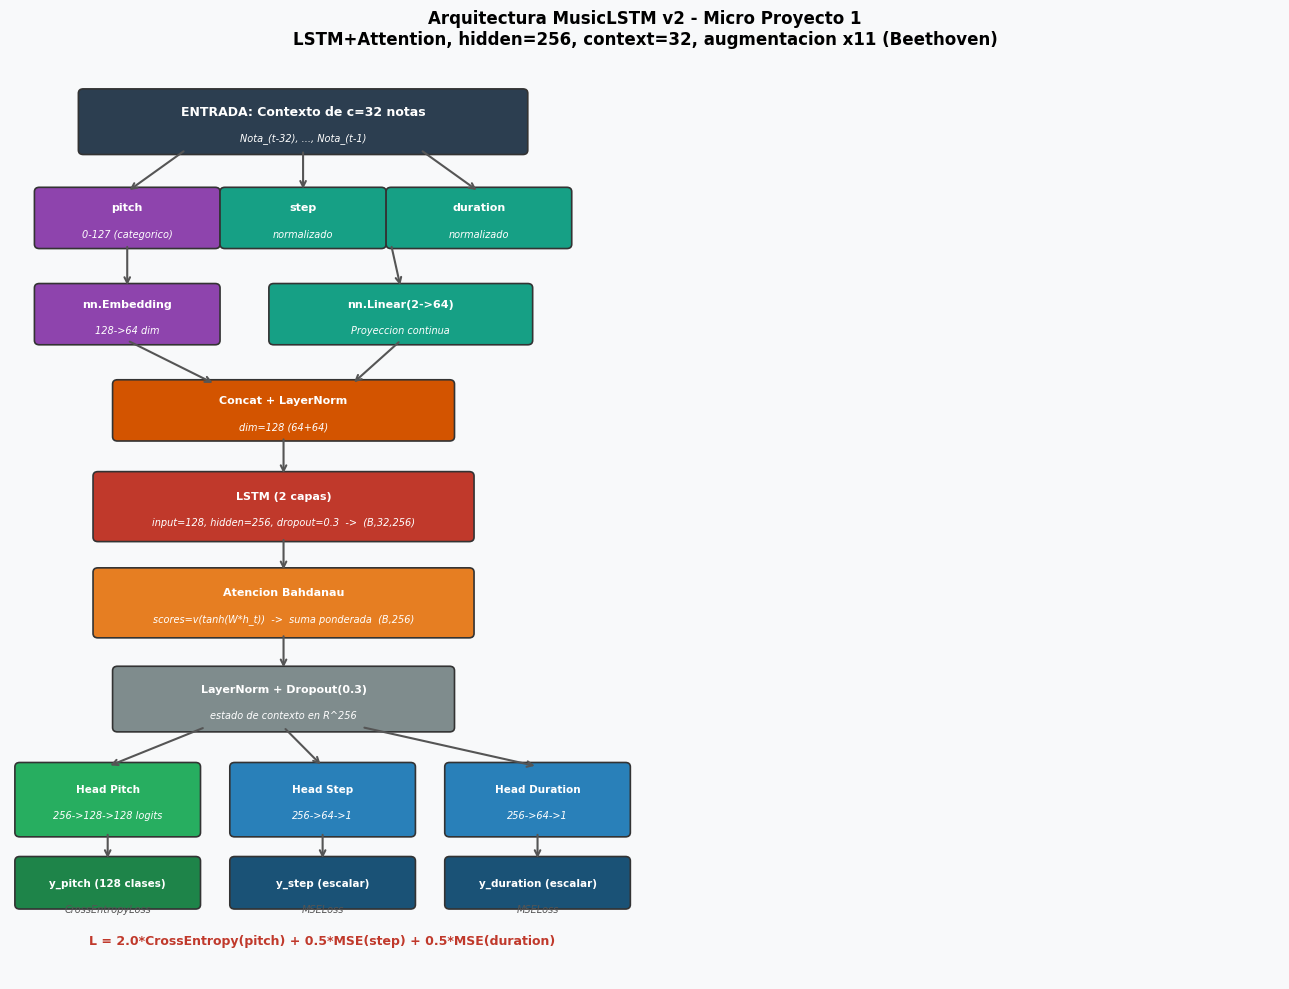

arquitectura_modelo.png guardado


In [7]:
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111)
ax.set_xlim(0, 13); ax.set_ylim(-0.3, 10.2); ax.axis('off')
fig.patch.set_facecolor('#f8f9fa'); ax.set_facecolor('#f8f9fa')

def box(ax, x, y, w, h, label, sub='', color='#4a90d9', tc='white', fs=9):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.05',
                                 facecolor=color, edgecolor='#333', linewidth=1.2)
    ax.add_patch(r)
    ax.text(x, y+(0.12 if sub else 0), label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc)
    if sub: ax.text(x, y-0.18, sub, ha='center', va='center', fontsize=7, color=tc, style='italic')

def arr(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

box(ax,3.0,9.5,4.5,0.65,'ENTRADA: Contexto de c=32 notas','Nota_(t-32), ..., Nota_(t-1)',color='#2c3e50')
box(ax,1.2,8.4,1.8,0.6,'pitch','0-127 (categorico)',color='#8e44ad',fs=8)
box(ax,3.0,8.4,1.6,0.6,'step','normalizado',color='#16a085',fs=8)
box(ax,4.8,8.4,1.8,0.6,'duration','normalizado',color='#16a085',fs=8)
arr(ax,1.8,9.18,1.2,8.7); arr(ax,3.0,9.18,3.0,8.7); arr(ax,4.2,9.18,4.8,8.7)
box(ax,1.2,7.3,1.8,0.6,'nn.Embedding','128->64 dim',color='#8e44ad',fs=8)
box(ax,4.0,7.3,2.6,0.6,'nn.Linear(2->64)','Proyeccion continua',color='#16a085',fs=8)
arr(ax,1.2,8.1,1.2,7.6); arr(ax,3.9,8.1,4.0,7.6)
box(ax,2.8,6.2,3.4,0.6,'Concat + LayerNorm','dim=128 (64+64)',color='#d35400',fs=8)
arr(ax,1.2,7.0,2.1,6.5); arr(ax,4.0,7.0,3.5,6.5)
box(ax,2.8,5.1,3.8,0.7,'LSTM (2 capas)','input=128, hidden=256, dropout=0.3  ->  (B,32,256)',color='#c0392b',fs=8)
arr(ax,2.8,5.9,2.8,5.45)
box(ax,2.8,4.0,3.8,0.7,'Atencion Bahdanau','scores=v(tanh(W*h_t))  ->  suma ponderada  (B,256)',color='#e67e22',fs=8)
arr(ax,2.8,4.75,2.8,4.35)
box(ax,2.8,2.9,3.4,0.65,'LayerNorm + Dropout(0.3)','estado de contexto en R^256',color='#7f8c8d',fs=8)
arr(ax,2.8,3.65,2.8,3.23)
box(ax,1.0,1.75,1.8,0.75,'Head Pitch','256->128->128 logits',color='#27ae60',fs=7.5)
box(ax,3.2,1.75,1.8,0.75,'Head Step','256->64->1',color='#2980b9',fs=7.5)
box(ax,5.4,1.75,1.8,0.75,'Head Duration','256->64->1',color='#2980b9',fs=7.5)
arr(ax,2.0,2.58,1.0,2.13); arr(ax,2.8,2.58,3.2,2.13); arr(ax,3.6,2.58,5.4,2.13)
box(ax,1.0,0.8,1.8,0.5,'y_pitch (128 clases)',color='#1e8449',fs=7.5)
box(ax,3.2,0.8,1.8,0.5,'y_step (escalar)',color='#1a5276',fs=7.5)
box(ax,5.4,0.8,1.8,0.5,'y_duration (escalar)',color='#1a5276',fs=7.5)
arr(ax,1.0,1.38,1.0,1.05); arr(ax,3.2,1.38,3.2,1.05); arr(ax,5.4,1.38,5.4,1.05)
ax.text(1.0,0.47,'CrossEntropyLoss',ha='center',fontsize=7,color='#555',style='italic')
ax.text(3.2,0.47,'MSELoss',ha='center',fontsize=7,color='#555',style='italic')
ax.text(5.4,0.47,'MSELoss',ha='center',fontsize=7,color='#555',style='italic')
ax.text(3.2,0.1,'L = 2.0*CrossEntropy(pitch) + 0.5*MSE(step) + 0.5*MSE(duration)',
        ha='center',fontsize=9,color='#c0392b',fontweight='bold')
ax.set_title('Arquitectura MusicLSTM v2 - Micro Proyecto 1\nLSTM+Attention, hidden=256, context=32, augmentacion x11 (Beethoven)',
             fontsize=12,fontweight='bold',pad=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'arquitectura_modelo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('arquitectura_modelo.png guardado')

In [8]:
class Attention(nn.Module):
    """Atencion Bahdanau: pondera cada paso del LSTM segun su relevancia."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
    def forward(self, lstm_out):  # lstm_out: (B, T, H)
        scores  = self.v(torch.tanh(self.W(lstm_out))).squeeze(-1)  # (B, T)
        weights = torch.softmax(scores, dim=-1)                      # (B, T)
        return (lstm_out * weights.unsqueeze(-1)).sum(dim=1)         # (B, H)

class MusicLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb   = nn.Embedding(NUM_PITCHES, EMBED_DIM)
        self.proj  = nn.Linear(2, EMBED_DIM)
        self.norm0 = nn.LayerNorm(EMBED_DIM * 2)
        self.lstm  = nn.LSTM(EMBED_DIM*2, HIDDEN_DIM, NUM_LAYERS,
                             batch_first=True, dropout=DROPOUT)
        self.attn  = Attention(HIDDEN_DIM)   # v2: atencion
        self.norm1 = nn.LayerNorm(HIDDEN_DIM)
        self.drop  = nn.Dropout(DROPOUT)
        self.h_pit = nn.Sequential(
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM // 2), nn.ReLU(),
            nn.Dropout(DROPOUT), nn.Linear(HIDDEN_DIM // 2, NUM_PITCHES))
        self.h_stp = nn.Sequential(
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM // 4), nn.ReLU(),
            nn.Linear(HIDDEN_DIM // 4, 1))
        self.h_dur = nn.Sequential(
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM // 4), nn.ReLU(),
            nn.Linear(HIDDEN_DIM // 4, 1))

    def forward(self, x):
        e = self.norm0(torch.cat([self.emb(x[:,:,0].long()), self.proj(x[:,:,1:])], dim=-1))
        lstm_out, _ = self.lstm(e)
        h = self.drop(self.norm1(self.attn(lstm_out)))  # atencion en lugar de ultimo estado
        return self.h_pit(h), self.h_stp(h).squeeze(1), self.h_dur(h).squeeze(1)

model = MusicLSTM().to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Parametros entrenables: {params:,}')

MusicLSTM(
  (emb): Embedding(128, 64)
  (proj): Linear(in_features=2, out_features=64, bias=True)
  (norm0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (attn): Attention(
    (W): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.3, inplace=False)
  (h_pit): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (h_stp): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (h_dur): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features

## 7. Entrenamiento

In [9]:
ce  = nn.CrossEntropyLoss()
mse = nn.MSELoss()
opt = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)

def loss_fn(pl, sp, dp, yp, ys, yd):
    return LAMBDA_PITCH*ce(pl,yp) + LAMBDA_STEP*mse(sp,ys) + LAMBDA_DUR*mse(dp,yd)

def run_epoch(ld, train=True):
    model.train() if train else model.eval()
    tot, ok, n = 0., 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, yp, ys, yd in ld:
            x, yp, ys, yd = x.to(DEVICE), yp.to(DEVICE), ys.to(DEVICE), yd.to(DEVICE)
            pl, sp, dp = model(x)
            loss = loss_fn(pl, sp, dp, yp, ys, yd)
            if train:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            tot += loss.item() * x.size(0)
            ok  += (pl.argmax(-1) == yp).sum().item()
            n   += x.size(0)
    return tot/n, ok/n

tr_l, vl_l, tr_a, vl_a = [], [], [], []
best, best_path = float('inf'), os.path.join(OUTPUT_DIR, 'best_model_t4_v2.pt')

for ep in range(1, EPOCHS+1):
    tl, ta = run_epoch(train_ld, True)
    vl, va = run_epoch(val_ld, False)
    sch.step()
    tr_l.append(tl); vl_l.append(vl); tr_a.append(ta); vl_a.append(va)
    if vl < best:
        best = vl; torch.save(model.state_dict(), best_path)
    print(f'Epoch {ep:3d}/{EPOCHS} | TrLoss={tl:.4f} VlLoss={vl:.4f} | TrAcc={ta:.3f} VlAcc={va:.3f}')

print(f'Mejor val loss: {best:.4f}')

Epoch   1/100 | TrLoss=6.1811 VlLoss=5.7739 | TrAcc=0.163 VlAcc=0.201
Epoch   2/100 | TrLoss=5.2407 VlLoss=5.3258 | TrAcc=0.285 VlAcc=0.300
Epoch   3/100 | TrLoss=4.8408 VlLoss=5.1164 | TrAcc=0.353 VlAcc=0.337
Epoch   4/100 | TrLoss=4.5945 VlLoss=5.0277 | TrAcc=0.391 VlAcc=0.351
Epoch   5/100 | TrLoss=4.4169 VlLoss=4.9847 | TrAcc=0.416 VlAcc=0.360
Epoch   6/100 | TrLoss=4.2736 VlLoss=4.9761 | TrAcc=0.435 VlAcc=0.353
Epoch   7/100 | TrLoss=4.1551 VlLoss=4.9700 | TrAcc=0.449 VlAcc=0.367
Epoch   8/100 | TrLoss=4.0601 VlLoss=5.0061 | TrAcc=0.460 VlAcc=0.366
Epoch   9/100 | TrLoss=3.9660 VlLoss=5.0632 | TrAcc=0.471 VlAcc=0.364
Epoch  10/100 | TrLoss=3.8865 VlLoss=4.9873 | TrAcc=0.480 VlAcc=0.371
Epoch  11/100 | TrLoss=3.8162 VlLoss=5.1652 | TrAcc=0.488 VlAcc=0.362
Epoch  12/100 | TrLoss=3.7531 VlLoss=5.0900 | TrAcc=0.494 VlAcc=0.376
Epoch  13/100 | TrLoss=3.6914 VlLoss=5.1339 | TrAcc=0.502 VlAcc=0.360
Epoch  14/100 | TrLoss=3.6373 VlLoss=5.2165 | TrAcc=0.506 VlAcc=0.358
Epoch  15/100 | TrLo

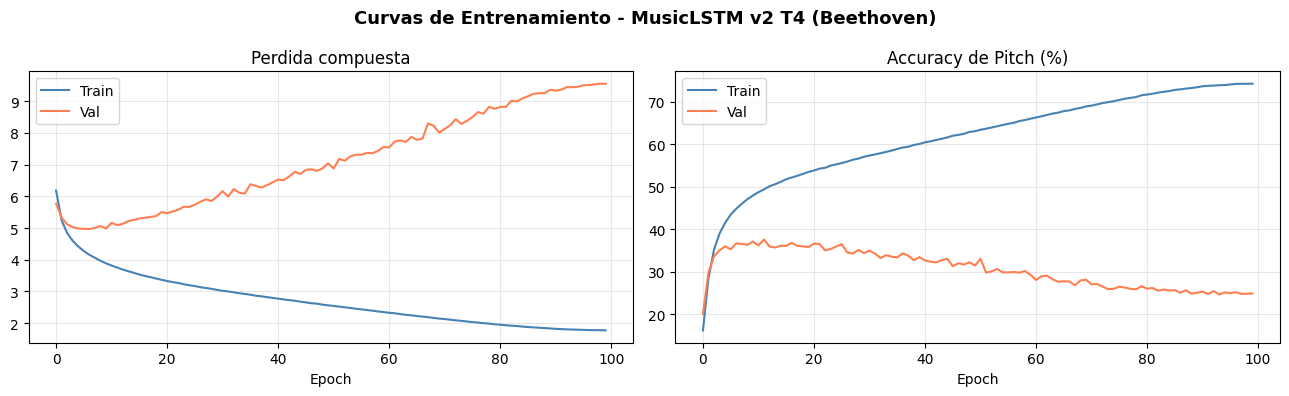

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(tr_l, label='Train', color='steelblue'); ax[0].plot(vl_l, label='Val', color='coral')
ax[0].set_title('Perdida compuesta'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot([a*100 for a in tr_a], label='Train', color='steelblue')
ax[1].plot([a*100 for a in vl_a], label='Val',   color='coral')
ax[1].set_title('Accuracy de Pitch (%)'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.suptitle('Curvas de Entrenamiento - MusicLSTM v2 T4 (Beethoven)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'curvas_entrenamiento.png'), dpi=120)
plt.show()

## 8. Generacion con Top-k Sampling (k=10)

In [11]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
print('Mejor modelo cargado.')

def topk_sample(logits, temp=1.0, k=TOP_K):
    scaled = logits / temp
    topk_vals, topk_idx = torch.topk(scaled, k)
    filtered = torch.full_like(scaled, float('-inf'))
    filtered.scatter_(0, topk_idx, topk_vals)
    probs = torch.softmax(filtered, dim=-1).cpu().numpy()
    return int(np.random.choice(NUM_PITCHES, p=probs))

def generate(seed, n=200, temp=1.0):
    ctx = list(seed[-CONTEXT_SIZE:])
    out = []
    with torch.no_grad():
        for _ in range(n):
            x = torch.tensor(
                np.array([[note['pitch'], ns(note['step']), nd(note['duration'])]
                          for note in ctx], dtype=np.float32)).unsqueeze(0).to(DEVICE)
            pl, sp, dp = model(x)
            pitch = topk_sample(pl[0], temp=temp)
            step  = max(0.0,  dns(sp[0].item()))
            dur   = max(0.05, dnd(dp[0].item()))
            note  = {'pitch': pitch, 'step': step, 'duration': dur, 'velocity': 80}
            out.append(note); ctx.append(note); ctx = ctx[-CONTEXT_SIZE:]
    return out

def to_midi(notes, path):
    pm  = pretty_midi.PrettyMIDI()
    ins = pretty_midi.Instrument(
        program=pretty_midi.instrument_name_to_program('Acoustic Grand Piano'))
    t = 0.0
    for n in notes:
        t += n['step']
        ins.notes.append(pretty_midi.Note(
            velocity=80, pitch=int(n['pitch']), start=t, end=t+n['duration']))
    pm.instruments.append(ins); pm.write(path)

def to_wav(mid_path, wav_path, sr=44100):
    audio = pretty_midi.PrettyMIDI(mid_path).synthesize(fs=sr)
    wavfile.write(wav_path, sr,
                  np.int16(audio / (np.max(np.abs(audio))+1e-8) * 32767))

seed_notes = all_sequences[0]
cfgs = [
    (0.8, 'beethoven_gen_1', 'conservador T=0.8'),
    (1.0, 'beethoven_gen_2', 'neutral T=1.0'),
    (1.2, 'beethoven_gen_3', 'creativo T=1.2'),
]
gens = []
for temp, name, desc in cfgs:
    print(f'Generando {name} ({desc})...')
    g = generate(seed_notes, n=200, temp=temp)
    gens.append(g)
    mid = os.path.join(OUTPUT_DIR, f'{name}.mid')
    wav = os.path.join(OUTPUT_DIR, f'{name}.wav')
    to_midi(g, mid); to_wav(mid, wav)
    print(f'  {name}.wav ({os.path.getsize(wav)//1024} KB)')

Mejor modelo cargado.
Generando beethoven_gen_1 (conservador T=0.8)...
  beethoven_gen_1.wav (4888 KB)
Generando beethoven_gen_2 (neutral T=1.0)...
  beethoven_gen_2.wav (3032 KB)
Generando beethoven_gen_3 (creativo T=1.2)...
  beethoven_gen_3.wav (1641 KB)


## 9. Analisis de resultados

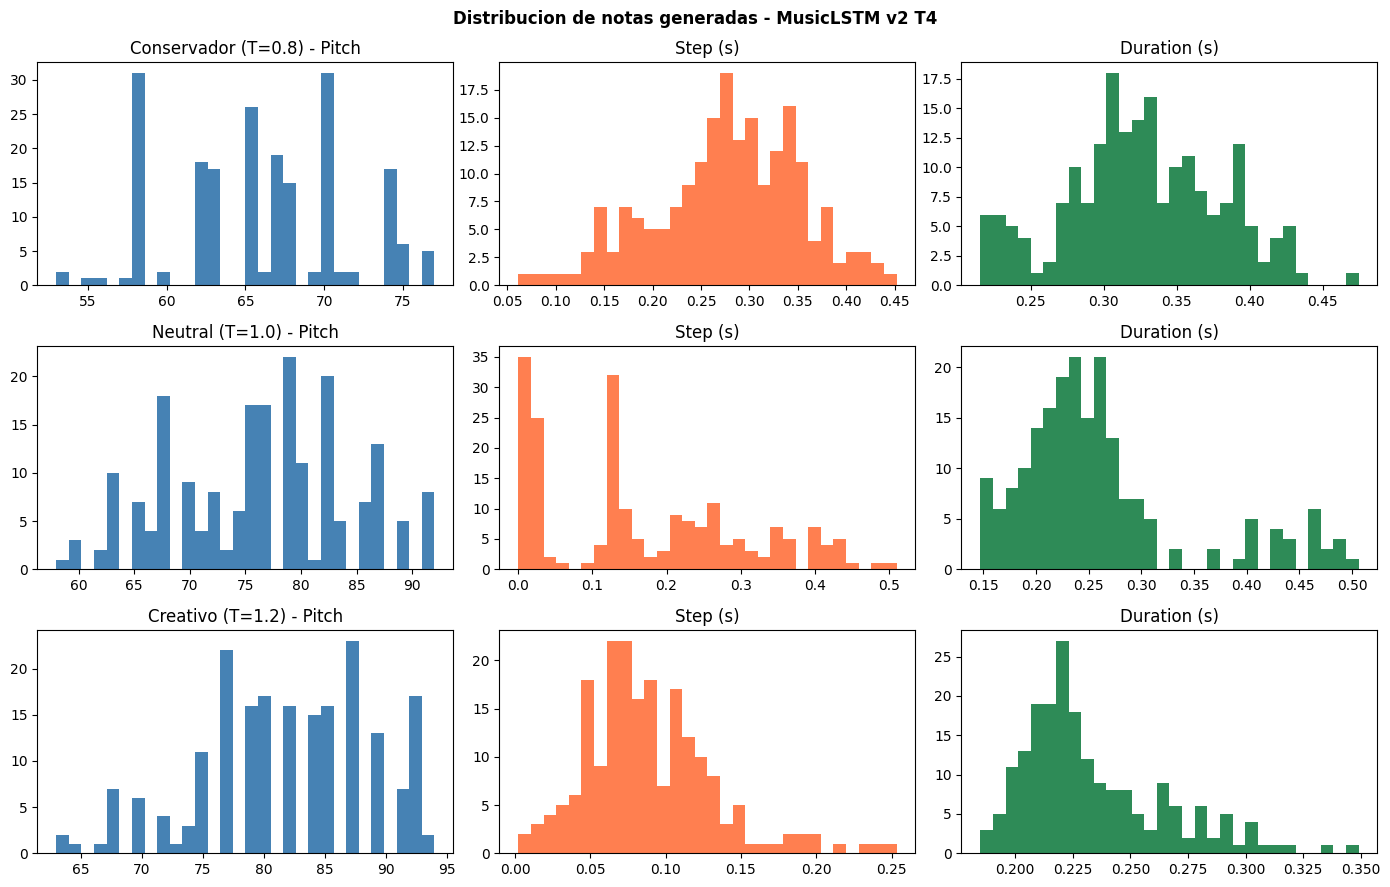

Val Loss final  : 4.9700
Pitch Accuracy  : 0.3673 (36.7%)


In [12]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
labels = ['Conservador (T=0.8)', 'Neutral (T=1.0)', 'Creativo (T=1.2)']
for i, (g, lbl) in enumerate(zip(gens, labels)):
    axes[i][0].hist([n['pitch']    for n in g], bins=30, color='steelblue')
    axes[i][0].set_title(f'{lbl} - Pitch')
    axes[i][1].hist([n['step']     for n in g], bins=30, color='coral')
    axes[i][1].set_title('Step (s)')
    axes[i][2].hist([n['duration'] for n in g], bins=30, color='seagreen')
    axes[i][2].set_title('Duration (s)')
plt.suptitle('Distribucion de notas generadas - MusicLSTM v2 T4', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'analisis_generacion.png'), dpi=100)
plt.show()

vl_f, va_f = run_epoch(val_ld, False)
print('='*50)
print(f'Val Loss final  : {vl_f:.4f}')
print(f'Pitch Accuracy  : {va_f:.4f} ({va_f*100:.1f}%)')
print('='*50)

## 10. Descargar archivos generados

In [13]:
from google.colab import files

for f in ['arquitectura_modelo.png', 'curvas_entrenamiento.png', 'analisis_generacion.png',
          'beethoven_gen_1.wav', 'beethoven_gen_2.wav', 'beethoven_gen_3.wav',
          'beethoven_gen_1.mid', 'beethoven_gen_2.mid', 'beethoven_gen_3.mid']:
    path = os.path.join(OUTPUT_DIR, f)
    if os.path.exists(path):
        files.download(path)
        print(f'Descargando {f}...')
print('Listo.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando arquitectura_modelo.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargando beethoven_gen_2.mid...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando beethoven_gen_3.mid...
Listo.
